In [12]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
import seaborn as sns
from scipy import stats
from scgen.file_utils import ensure_dir, to_dense
sc.set_figure_params(dpi_save=300)

In [13]:
path_to_save = "../results/Figures/Supplemental Figure 7/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [14]:
def umap_visualize(adata, n_out, figure, palette):
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.pl.umap(adata, color=["heldout"],
               legend_fontsize=20,
               palette=palette,
               frameon=False,
               title="",
               save=f"_heldout_{n_out}.png",
               show=True)
    os.rename(src=os.path.join(path_to_save, f"umap_heldout_{n_out}.png"), 
              dst=os.path.join(path_to_save, f"SupplFig6{figure}_heldout_{n_out}.png"))

In [15]:
def umap_heldout(adata, c_in, c_out, figure):
    adata.obs["heldout"] = "train/validation"
    adata.obs.loc[(adata.obs["cell_type"].isin(c_out)) & (adata.obs["condition"] == "stimulated"), "heldout"] = "holdout"
    print(adata.obs.groupby(['heldout']).size())
    print(adata.obs.groupby(['cell_type', 'heldout']).size())
    umap_visualize(adata, len(c_out), figure, palette=["#22c2e5", "#ffd600"])

In [16]:
def replace_conditions(adata):
    adata.obs["condition"].replace("CD4T_ctrl", "CD4-T_ctrl", inplace=True)
    adata.obs["condition"].replace("CD4T_real_stim", "CD4-T_real_stim", inplace=True)
    adata.obs["condition"].replace("CD4T_pred_stim", "CD4-T_pred_stim", inplace=True)

    adata.obs["condition"].replace("CD8T_ctrl", "CD8-T_ctrl", inplace=True)
    adata.obs["condition"].replace("CD8T_real_stim", "CD8-T_real_stim", inplace=True)
    adata.obs["condition"].replace("CD8T_pred_stim", "CD8-T_pred_stim", inplace=True)

    adata.obs["condition"].replace("Dendritic_ctrl", "DC_ctrl", inplace=True)
    adata.obs["condition"].replace("Dendritic_real_stim", "DC_real_stim", inplace=True)
    adata.obs["condition"].replace("Dendritic_pred_stim", "DC_pred_stim", inplace=True)

    adata.obs["condition"].replace("FCGR3A+Mono_ctrl", "F-Mono_ctrl", inplace=True)
    adata.obs["condition"].replace("FCGR3A+Mono_real_stim", "F-Mono_real_stim", inplace=True)
    adata.obs["condition"].replace("FCGR3A+Mono_pred_stim", "F-Mono_pred_stim", inplace=True)

    adata.obs["condition"].replace("CD14+Mono_ctrl", "CD14-Mono_ctrl", inplace=True)
    adata.obs["condition"].replace("CD14+Mono_real_stim", "CD14-Mono_real_stim", inplace=True)
    adata.obs["condition"].replace("CD14+Mono_pred_stim", "CD14-Mono_pred_stim", inplace=True)
def replace_cell_types(adata):
    adata.obs["cell_type"].replace("CD4T", "CD4-T", inplace=True)
    adata.obs["cell_type"].replace("CD8T", "CD8-T", inplace=True)
    adata.obs["cell_type"].replace("Dendritic", "DC", inplace=True)
    adata.obs["cell_type"].replace("FCGR3A+Mono", "F-Mono", inplace=True)
    adata.obs["cell_type"].replace("CD14+Mono", "CD14-Mono", inplace=True)

In [17]:
pbmc = scgen.load_file("../data/train_pbmc.h5ad")
replace_cell_types(pbmc)
pbmc

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(
/tmp/ipykernel_30299/2754653650.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(va

AnnData object with n_obs × n_vars = 16893 × 6998
    obs: 'condition', 'n_counts', 'n_genes', 'mt_frac', 'cell_type'
    var: 'gene_symbol', 'n_cells'
    uns: 'cell_type_colors', 'condition_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

In [18]:
pbmc.obs.groupby(['cell_type', 'condition']).size()

/tmp/ipykernel_30299/191267336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pbmc.obs.groupby(['cell_type', 'condition']).size()


cell_type  condition 
CD4-T      control       2437
           stimulated    3127
CD14-Mono  control       1946
           stimulated     615
B          control        818
           stimulated     993
CD8-T      control        574
           stimulated     541
NK         control        517
           stimulated     646
F-Mono     control       1100
           stimulated    2501
DC         control        615
           stimulated     463
dtype: int64

In [19]:
def cell_type_analysis(adata, cell_type, n_out, figure, c_in, c_out):
    adata = to_dense(adata)
    network = scgen.VAEArith(x_dimension=adata.shape[1], z_dimension=100, model_path=f"../models/scGen/pbmc/heldout/{n_out}/scgen")
    network.restore_model()
    net_train_data = scgen.data_remover(adata, remain_list=c_in, remove_list=c_out,
                                        cell_type_key="cell_type", condition_key="condition")
    print(net_train_data.obs.groupby(['cell_type', 'condition']).size())
    conditions = {"stim": "stimulated", "ctrl": "control"}
    pred_stim, delta = network.predict(adata=net_train_data,
                                       conditions=conditions,
                                       cell_type_key="cell_type",
                                       condition_key="condition",
                                       celltype_to_predict=cell_type)
    cell_type_data = adata[adata.obs["cell_type"] == cell_type]
    pred_adata = anndata.AnnData(pred_stim, obs={"condition": ["pred"] * len(pred_stim)},
                                 var={"var_names": cell_type_data.var_names})
    
    all_adata = cell_type_data.concatenate(pred_adata)
    print(all_adata.obs.groupby(['condition']).size())
    sc.tl.rank_genes_groups(cell_type_data, groupby="condition", n_genes=100, method="wilcoxon")
    diff_genes = cell_type_data.uns["rank_genes_groups"]["names"]["stimulated"]
    scgen.plotting.reg_mean_plot(all_adata, 
                                 labels={"x": "pred", "y":"stim"},
                                 condition_key="condition",
                                 axis_keys={"x": "pred", "y": conditions["stim"]},
                                 gene_list=diff_genes[:5],
                                 top_100_genes=diff_genes,
                                 legend=False,
                                 fontsize=20,
                                 textsize=14, 
                                 range=[0, 6, 1],
                                 x_coeff=0.35,
                                 show=True,
                                 path_to_save=os.path.join(path_to_save, f"SupplFig7{figure}_{cell_type}_reg_mean.pdf"))
    import matplotlib
    matplotlib.rc('ytick', labelsize=18)
    matplotlib.rc('xtick', labelsize=18)
    sc.pl.violin(all_adata, keys="ISG15", groupby="condition",
                 save=f"_ISG15.pdf",
                 color = "#ee0ef0",
                 show=True)
    ctrl = cell_type_data[cell_type_data.obs['condition'] == 'control']
    stim = cell_type_data[cell_type_data.obs['condition'] == 'stimulated']
    print(f"Control: {ctrl.shape[0]}")
    print(f"Prediction: {pred_adata.shape[0]}")
    print(f"Stimulated: {stim.shape[0]}")
    os.rename(src=os.path.join(path_to_save, f"violin_ISG15.pdf"), 
              dst=os.path.join(path_to_save, f"SupplFig7{figure}_violin_ISG15_{cell_type}_{n_out}.pdf"))

/tmp/ipykernel_30299/2452386946.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby(['cell_type', 'heldout']).size())


heldout
holdout              5628
train/validation    11265
dtype: int64
cell_type  heldout         
CD4-T      holdout             3127
           train/validation    2437
CD14-Mono  holdout                0
           train/validation    2561
B          holdout                0
           train/validation    1811
CD8-T      holdout                0
           train/validation    1115
NK         holdout                0
           train/validation    1163
F-Mono     holdout             2501
           train/validation    1100
DC         holdout                0
           train/validation    1078
dtype: int64


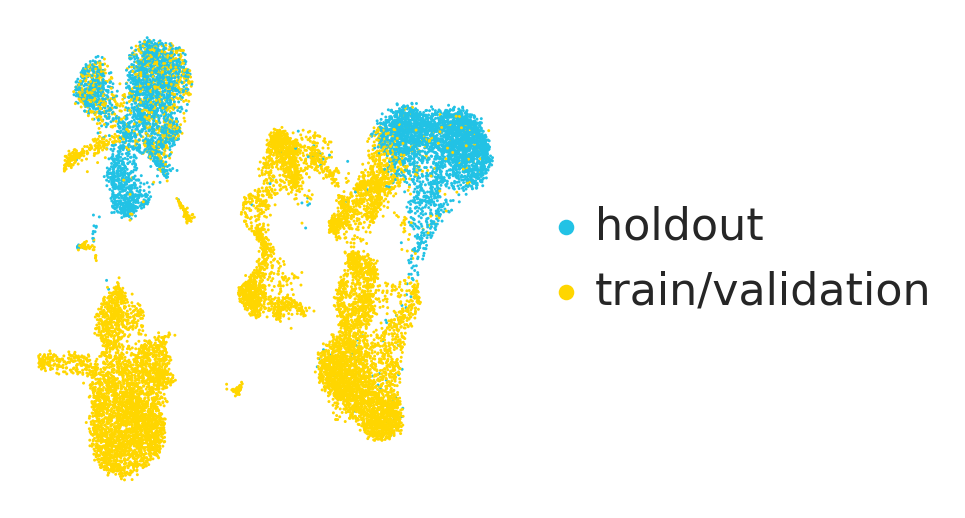

2026-02-20 03:27:31.914054: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/heldout/2/scgen
cell_type  condition 
B          control        818
           stimulated     993
CD14-Mono  control       1946
           stimulated     615
CD4-T      control       2437
CD8-T      control        574
           stimulated     541
DC         control        615
           stimulated     463
F-Mono     control       1100
NK         control        517
           stimulated     646
dtype: int64


/tmp/ipykernel_30299/1298360050.py:18: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_data.concatenate(pred_adata)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


condition
control       2437
pred          2437
stimulated    3127
dtype: int64
0.9632249877509573
0.9673746232196268


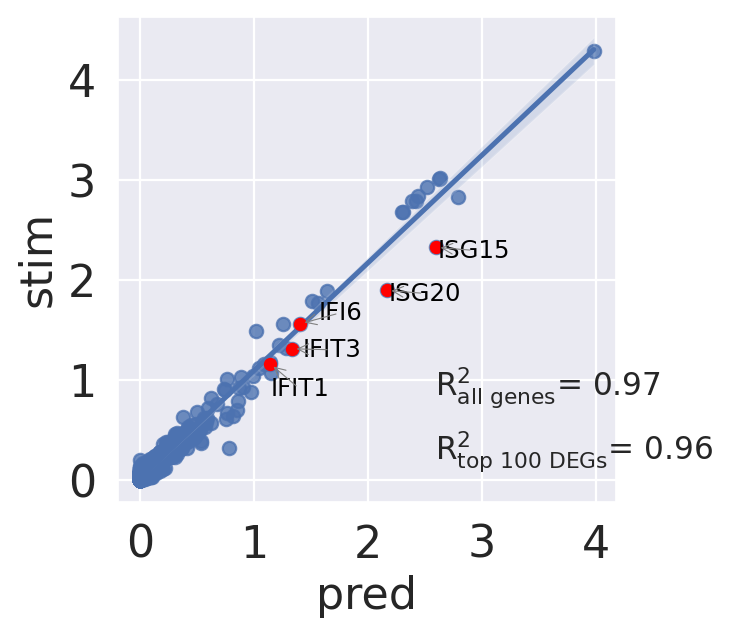

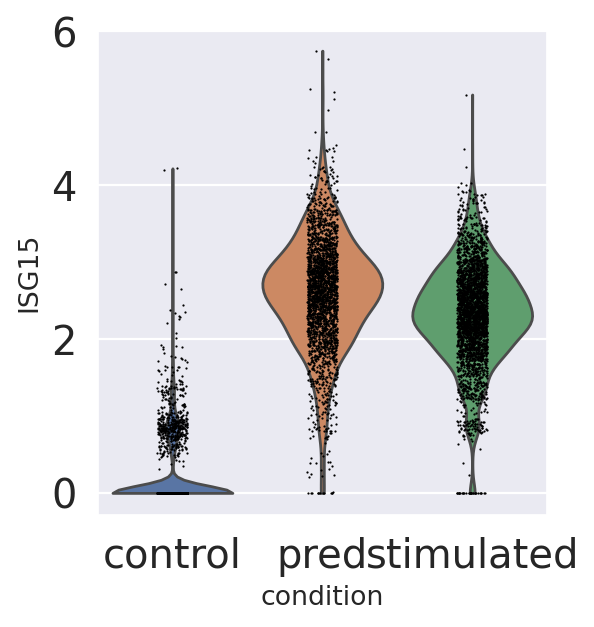

Control: 2437
Prediction: 2437
Stimulated: 3127


2026-02-20 03:27:37.059939: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/heldout/2/scgen
cell_type  condition 
B          control        818
           stimulated     993
CD14-Mono  control       1946
           stimulated     615
CD4-T      control       2437
CD8-T      control        574
           stimulated     541
DC         control        615
           stimulated     463
F-Mono     control       1100
NK         control        517
           stimulated     646
dtype: int64


/tmp/ipykernel_30299/1298360050.py:18: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_data.concatenate(pred_adata)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


condition
control       1100
pred          1100
stimulated    2501
dtype: int64
0.9267080629796633
0.9548205927431608


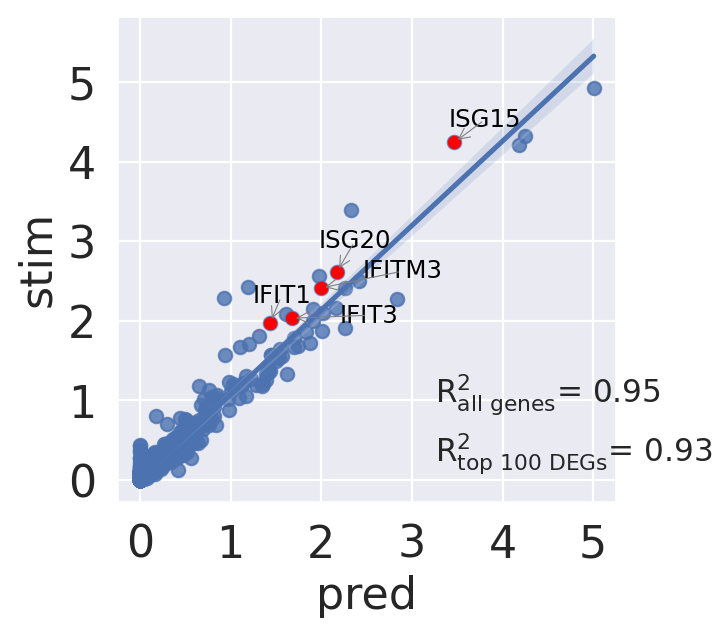

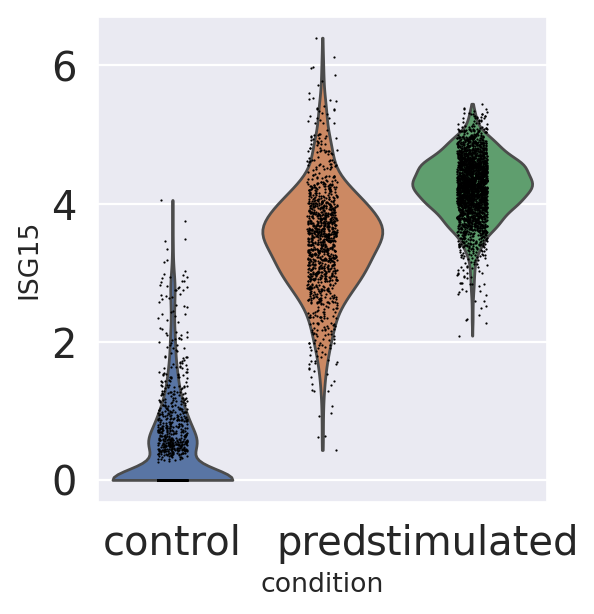

Control: 1100
Prediction: 1100
Stimulated: 2501


In [20]:
c_in = ['CD8-T', 'NK', 'B', 'DC', 'CD14-Mono']
c_out = ['CD4-T', 'F-Mono']
umap_heldout(pbmc, c_in, c_out, "a")
cell_type_analysis(pbmc, "CD4-T", 2, "a", c_in, c_out)
cell_type_analysis(pbmc, "F-Mono", 2, "a", c_in, c_out)

heldout
holdout              6632
train/validation    10261
dtype: int64
cell_type  heldout         
CD4-T      holdout             3127
           train/validation    2437
CD14-Mono  holdout                0
           train/validation    2561
B          holdout                0
           train/validation    1811
CD8-T      holdout              541
           train/validation     574
NK         holdout                0
           train/validation    1163
F-Mono     holdout             2501
           train/validation    1100
DC         holdout              463
           train/validation     615
dtype: int64


/tmp/ipykernel_30299/2452386946.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby(['cell_type', 'heldout']).size())


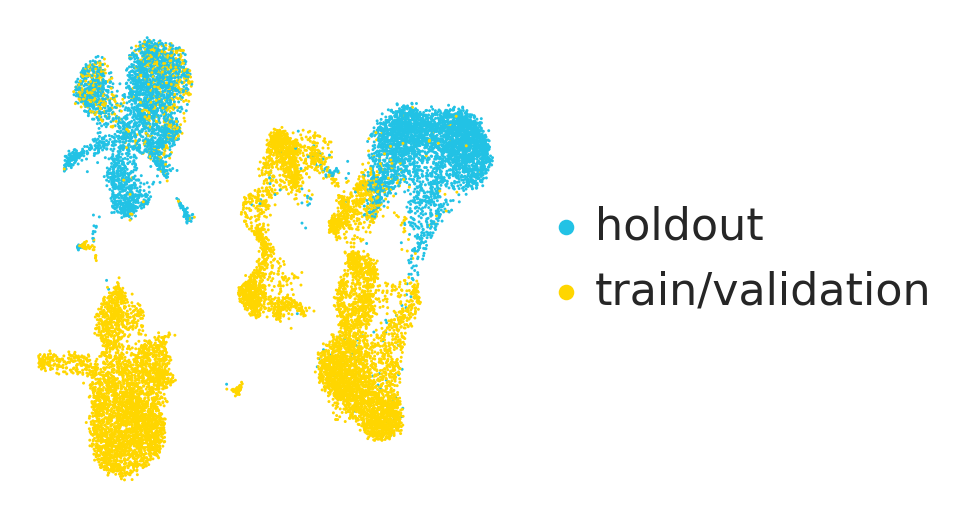

2026-02-20 03:27:52.155733: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/heldout/4/scgen
cell_type  condition 
B          control        818
           stimulated     993
CD14-Mono  control       1946
           stimulated     615
CD4-T      control       2437
CD8-T      control        574
DC         control        615
F-Mono     control       1100
NK         control        517
           stimulated     646
dtype: int64


/tmp/ipykernel_30299/1298360050.py:18: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_data.concatenate(pred_adata)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


condition
control       2437
pred          2437
stimulated    3127
dtype: int64
0.9577719809804975
0.9646177817933062


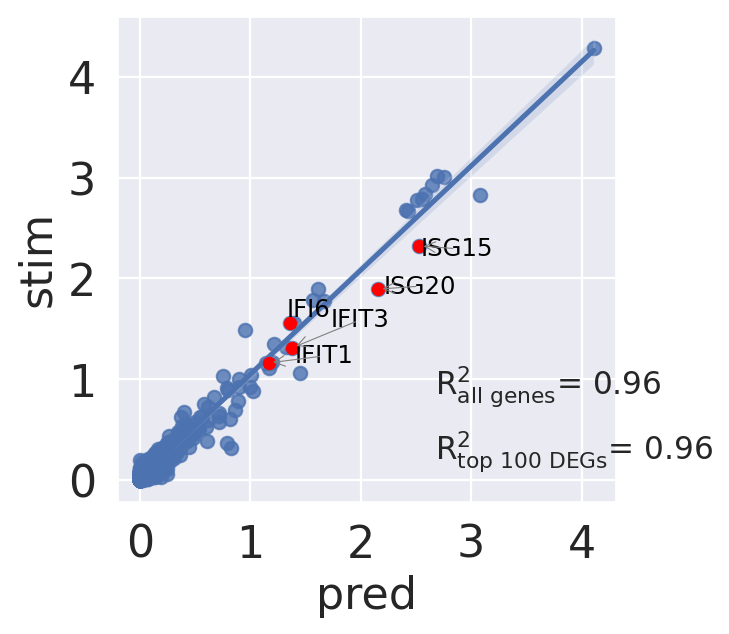

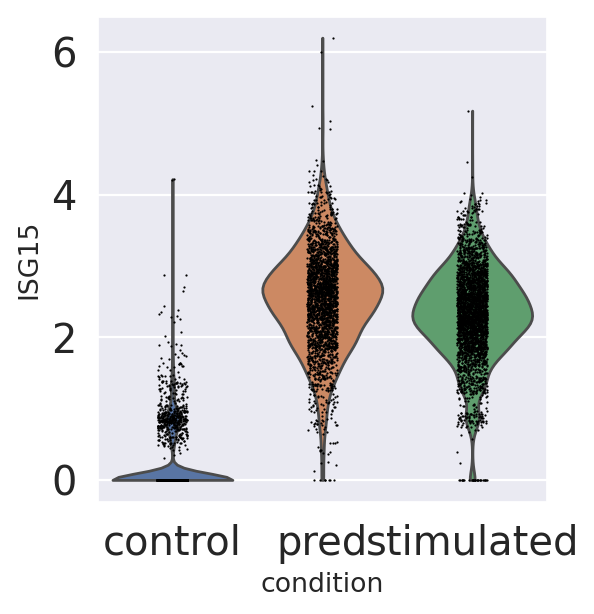

Control: 2437
Prediction: 2437
Stimulated: 3127


2026-02-20 03:27:57.584186: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/heldout/4/scgen
cell_type  condition 
B          control        818
           stimulated     993
CD14-Mono  control       1946
           stimulated     615
CD4-T      control       2437
CD8-T      control        574
DC         control        615
F-Mono     control       1100
NK         control        517
           stimulated     646
dtype: int64


/tmp/ipykernel_30299/1298360050.py:18: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_data.concatenate(pred_adata)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


condition
control       1100
pred          1100
stimulated    2501
dtype: int64
0.955142186765015
0.968360894491681


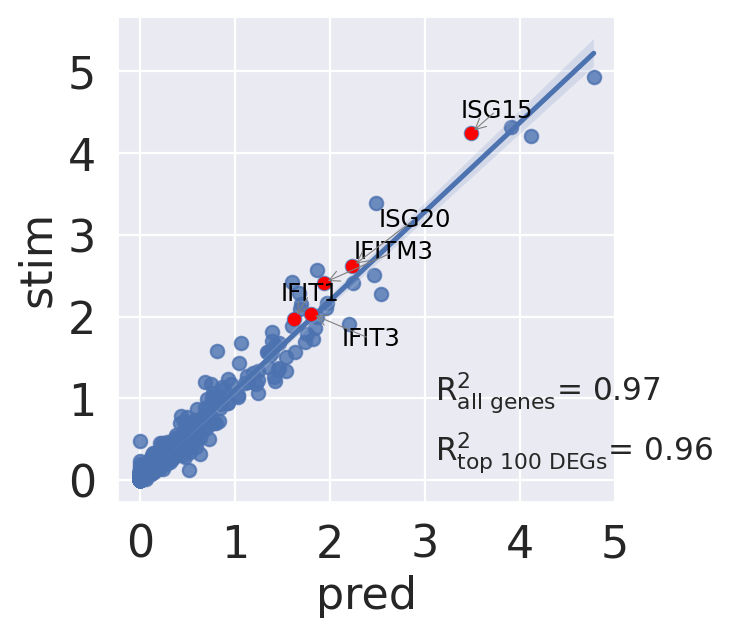

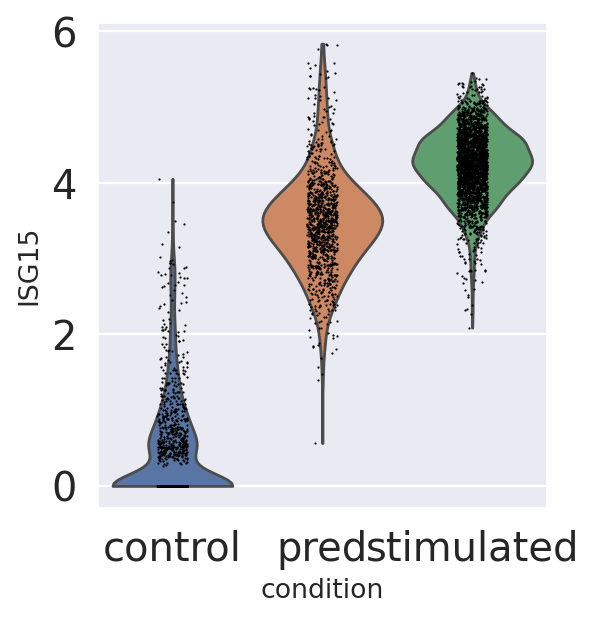

Control: 1100
Prediction: 1100
Stimulated: 2501


In [21]:
c_in = ['NK', 'B', 'CD14-Mono']
c_out = ['CD4-T', 'F-Mono', 'CD8-T', 'DC']
umap_heldout(pbmc, c_in, c_out, "b")
cell_type_analysis(pbmc, "CD4-T", 4, "b", c_in, c_out)
cell_type_analysis(pbmc, "F-Mono", 4, "b", c_in, c_out)

heldout
holdout             8271
train/validation    8622
dtype: int64
cell_type  heldout         
CD4-T      holdout             3127
           train/validation    2437
CD14-Mono  holdout                0
           train/validation    2561
B          holdout              993
           train/validation     818
CD8-T      holdout              541
           train/validation     574
NK         holdout              646
           train/validation     517
F-Mono     holdout             2501
           train/validation    1100
DC         holdout              463
           train/validation     615
dtype: int64


/tmp/ipykernel_30299/2452386946.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby(['cell_type', 'heldout']).size())


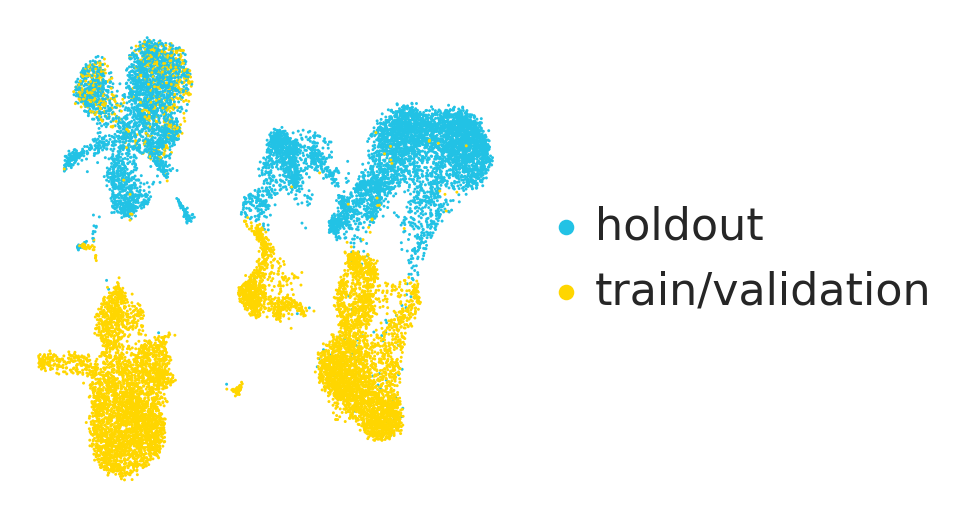

2026-02-20 03:28:15.496715: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/heldout/6/scgen
cell_type  condition 
B          control        818
CD14-Mono  control       1946
           stimulated     615
CD4-T      control       2437
CD8-T      control        574
DC         control        615
F-Mono     control       1100
NK         control        517
dtype: int64


/tmp/ipykernel_30299/1298360050.py:18: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_data.concatenate(pred_adata)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


condition
control       2437
pred          2437
stimulated    3127
dtype: int64
0.6878905782437874
0.6413966147303277


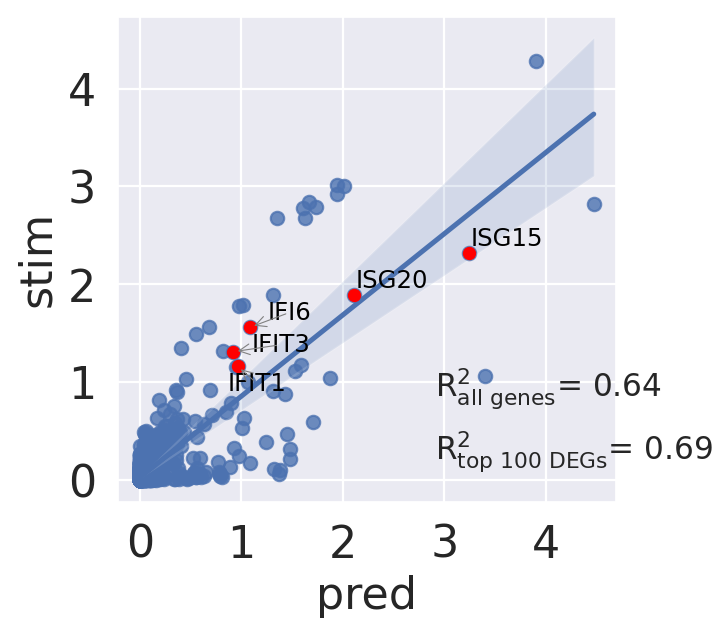

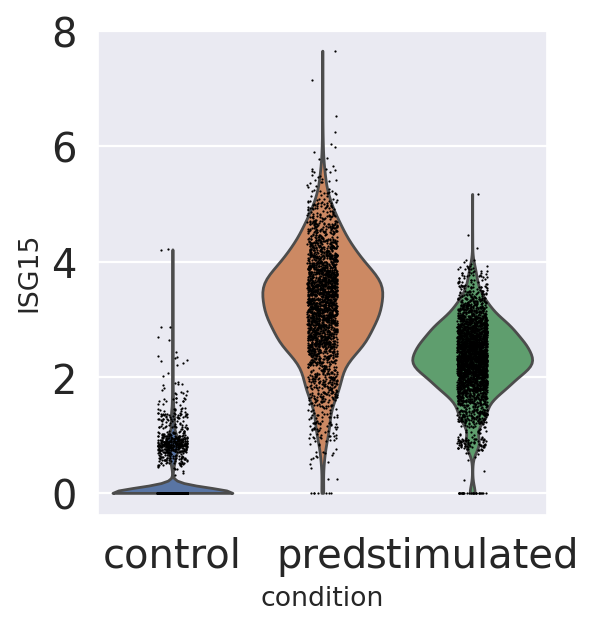

Control: 2437
Prediction: 2437
Stimulated: 3127


2026-02-20 03:28:20.476485: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/heldout/6/scgen
cell_type  condition 
B          control        818
CD14-Mono  control       1946
           stimulated     615
CD4-T      control       2437
CD8-T      control        574
DC         control        615
F-Mono     control       1100
NK         control        517
dtype: int64


/tmp/ipykernel_30299/1298360050.py:18: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_data.concatenate(pred_adata)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


condition
control       1100
pred          1100
stimulated    2501
dtype: int64
0.9225519578387466
0.9278199248422309


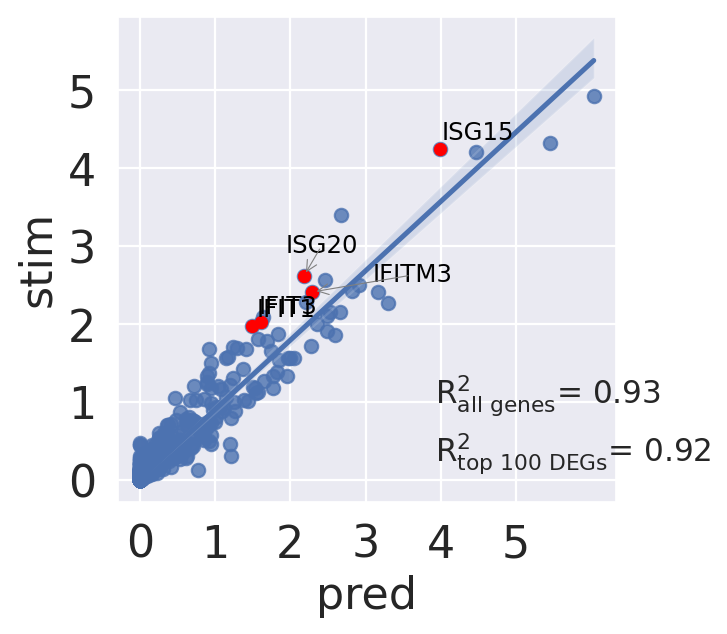

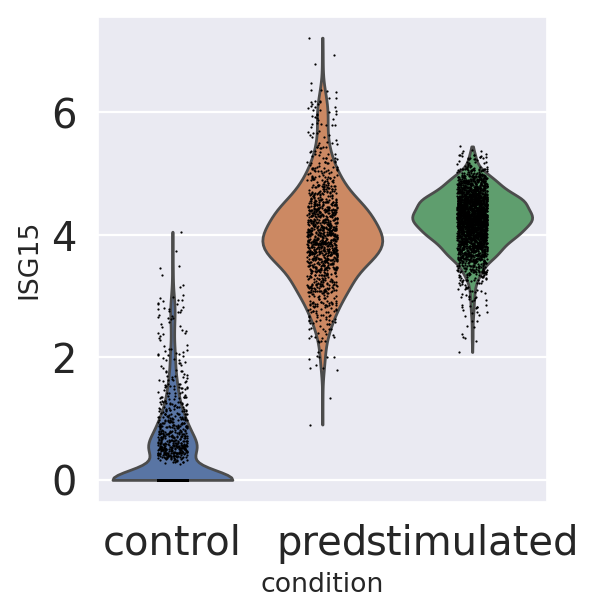

Control: 1100
Prediction: 1100
Stimulated: 2501


In [22]:
c_in = ['CD14-Mono']
c_out = ['CD4-T', 'F-Mono', 'CD8-T', 'NK', 'B', 'DC']
umap_heldout(pbmc, c_in, c_out, "c")
cell_type_analysis(pbmc, "CD4-T", 6, "c", c_in, c_out)
cell_type_analysis(pbmc, "F-Mono", 6, "c", c_in, c_out)